# Deliverable 2

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler, PowerTransformer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [20]:
df = pd.read_csv('CIS2022_PUMF_CLEANED.csv')

target = 'After-tax income'

features = [
    'Major source of income',
    "Person's age group as of December 31 of refyear",
    'Total usual hours worked at all jobs during refyear',
    'Yearly summary of time worked during the refyear',
    'Flag - Person was self-employed during refyear',
    'Flag - Person was a paid employee during refyear',
    'Number of weeks employed during refyear',
    'Flag - Person was employed during the reference year',
    'Average usual hours worked per week at all jobs during refyear',
    'Highest level of education of person, 2nd grouping',
    'Annual labour force status',
    'Flag - Attended school, college, CEGEP or university during refyear',
    'Age group of youngest person in economic family',
    'Full-time or part-time student during refyear',
    'Economic family type',
    'Number of weeks not in the labour force during refyear',
    'Age group of oldest person in economic family',
    'Marital status',
    'Flag - Person completed high school',
    'Census family composition',
]

df = df[features + [target]].dropna()
print(f'Dataset shape: {df.shape}')

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Dataset shape: (56573, 21)
Train: (45258, 20), Test: (11315, 20)


In [21]:
def evaluate(y_true, y_pred, n_features):
    n = len(y_true)
    r2 = r2_score(y_true, y_pred)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    # MAPE - avoid division by zero
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return {'R2': round(r2, 4), 'Adj_R2': round(adj_r2, 4),
            'RMSE': round(rmse, 2), 'MAE': round(mae, 2), 'MAPE': round(mape, 2)}

## Baseline Models (Before Transformation)

In [ ]:
n_feat = len(features)

# StandardScaler for SVR
scaler_baseline = StandardScaler()
X_train_scaled = pd.DataFrame(scaler_baseline.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler_baseline.transform(X_test), columns=X_test.columns, index=X_test.index)

baseline_models = {
    'Linear Regression': (LinearRegression(), X_train, X_test),
    'Decision Tree': (DecisionTreeRegressor(random_state=42), X_train, X_test),
    'Random Forest': (RandomForestRegressor(n_estimators=100, random_state=42), X_train, X_test),
    'SVR': (SVR(), X_train_scaled, X_test_scaled),
}

baseline_results = {}
for name, (model, X_tr, X_te) in baseline_models.items():
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    baseline_results[name] = evaluate(y_test, y_pred, n_feat)

baseline_df = pd.DataFrame(baseline_results).T
baseline_df

## Task 1: Outlier & Imbalance Analysis

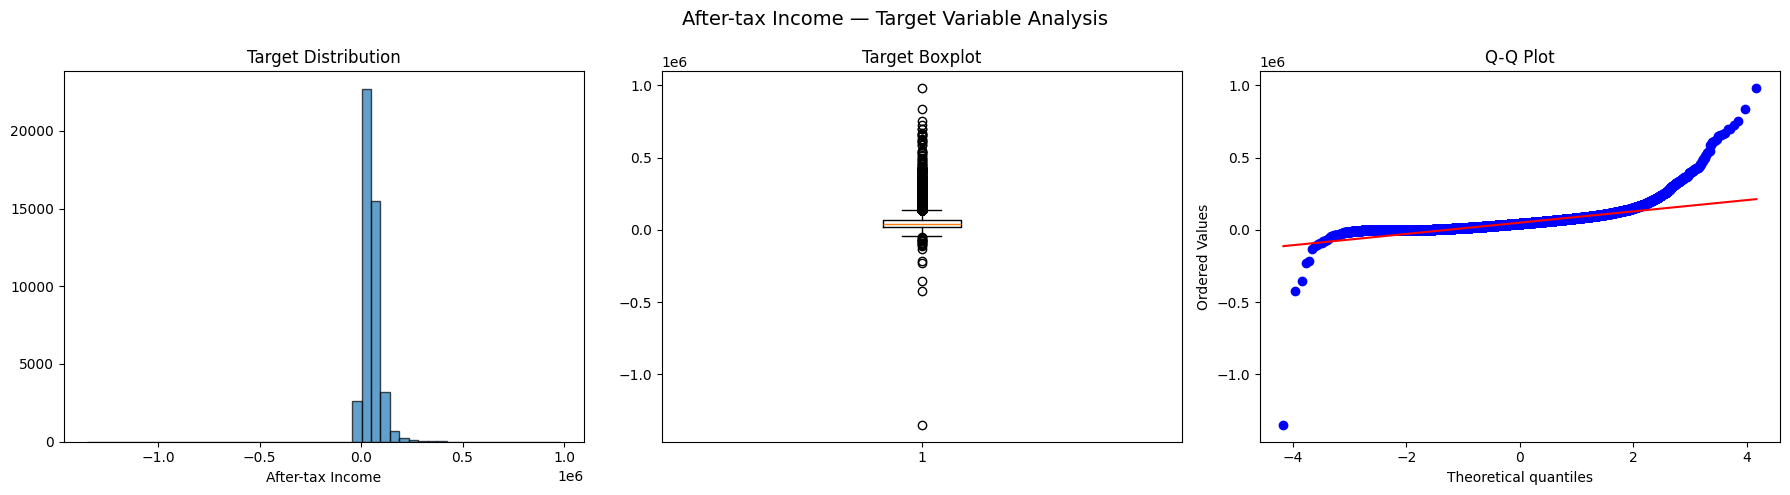

Skewness: 2.685
Kurtosis: 52.856


In [23]:
# Target distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(y_train, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Target Distribution')
axes[0].set_xlabel('After-tax Income')

axes[1].boxplot(y_train, vert=True)
axes[1].set_title('Target Boxplot')

stats.probplot(y_train, plot=axes[2])
axes[2].set_title('Q-Q Plot')

plt.suptitle('After-tax Income — Target Variable Analysis', fontsize=14)
plt.tight_layout()
plt.show()

print(f'Skewness: {y_train.skew():.3f}')
print(f'Kurtosis: {y_train.kurtosis():.3f}')

In [24]:
# Feature outlier summary (IQR method)
outlier_summary = []
for col in features:
    q1 = X_train[col].quantile(0.25)
    q3 = X_train[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_outliers = ((X_train[col] < lower) | (X_train[col] > upper)).sum()
    pct = n_outliers / len(X_train) * 100
    outlier_summary.append({
        'Feature': col[:50], 'Q1': q1, 'Q3': q3, 'IQR': iqr,
        'Outliers': n_outliers, '% Outliers': round(pct, 2),
        'Skewness': round(X_train[col].skew(), 3)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('% Outliers', ascending=False)
outlier_df

,Feature,Q1,Q3,IQR,Outliers,% Outliers,Skewness
4,Flag - Person was self-employed during refyear,2.0,2.0,0.0,15547,34.35,1.133
14,Economic family type,21.0,23.0,2.0,14110,31.18,1.331
19,Census family composition,3.0,4.0,1.0,11296,24.96,0.512
8,Average usual hours worked per week at all job...,35.0,62.0,27.0,10682,23.60,1.244
2,Total usual hours worked at all jobs during re...,1560.0,3120.0,1560.0,10673,23.58,1.133
7,Flag - Person was employed during the referenc...,1.0,1.0,0.0,10662,23.56,1.246
5,Flag - Person was a paid employee during refyear,1.0,2.0,1.0,10662,23.56,1.190
13,Full-time or part-time student during refyear,6.0,6.0,0.0,6048,13.36,-2.066
18,Flag - Person completed high school,1.0,1.0,0.0,5851,12.93,2.210
3,Yearly summary of time worked during the refyear,11.0,22.0,11.0,0,0.00,0.461


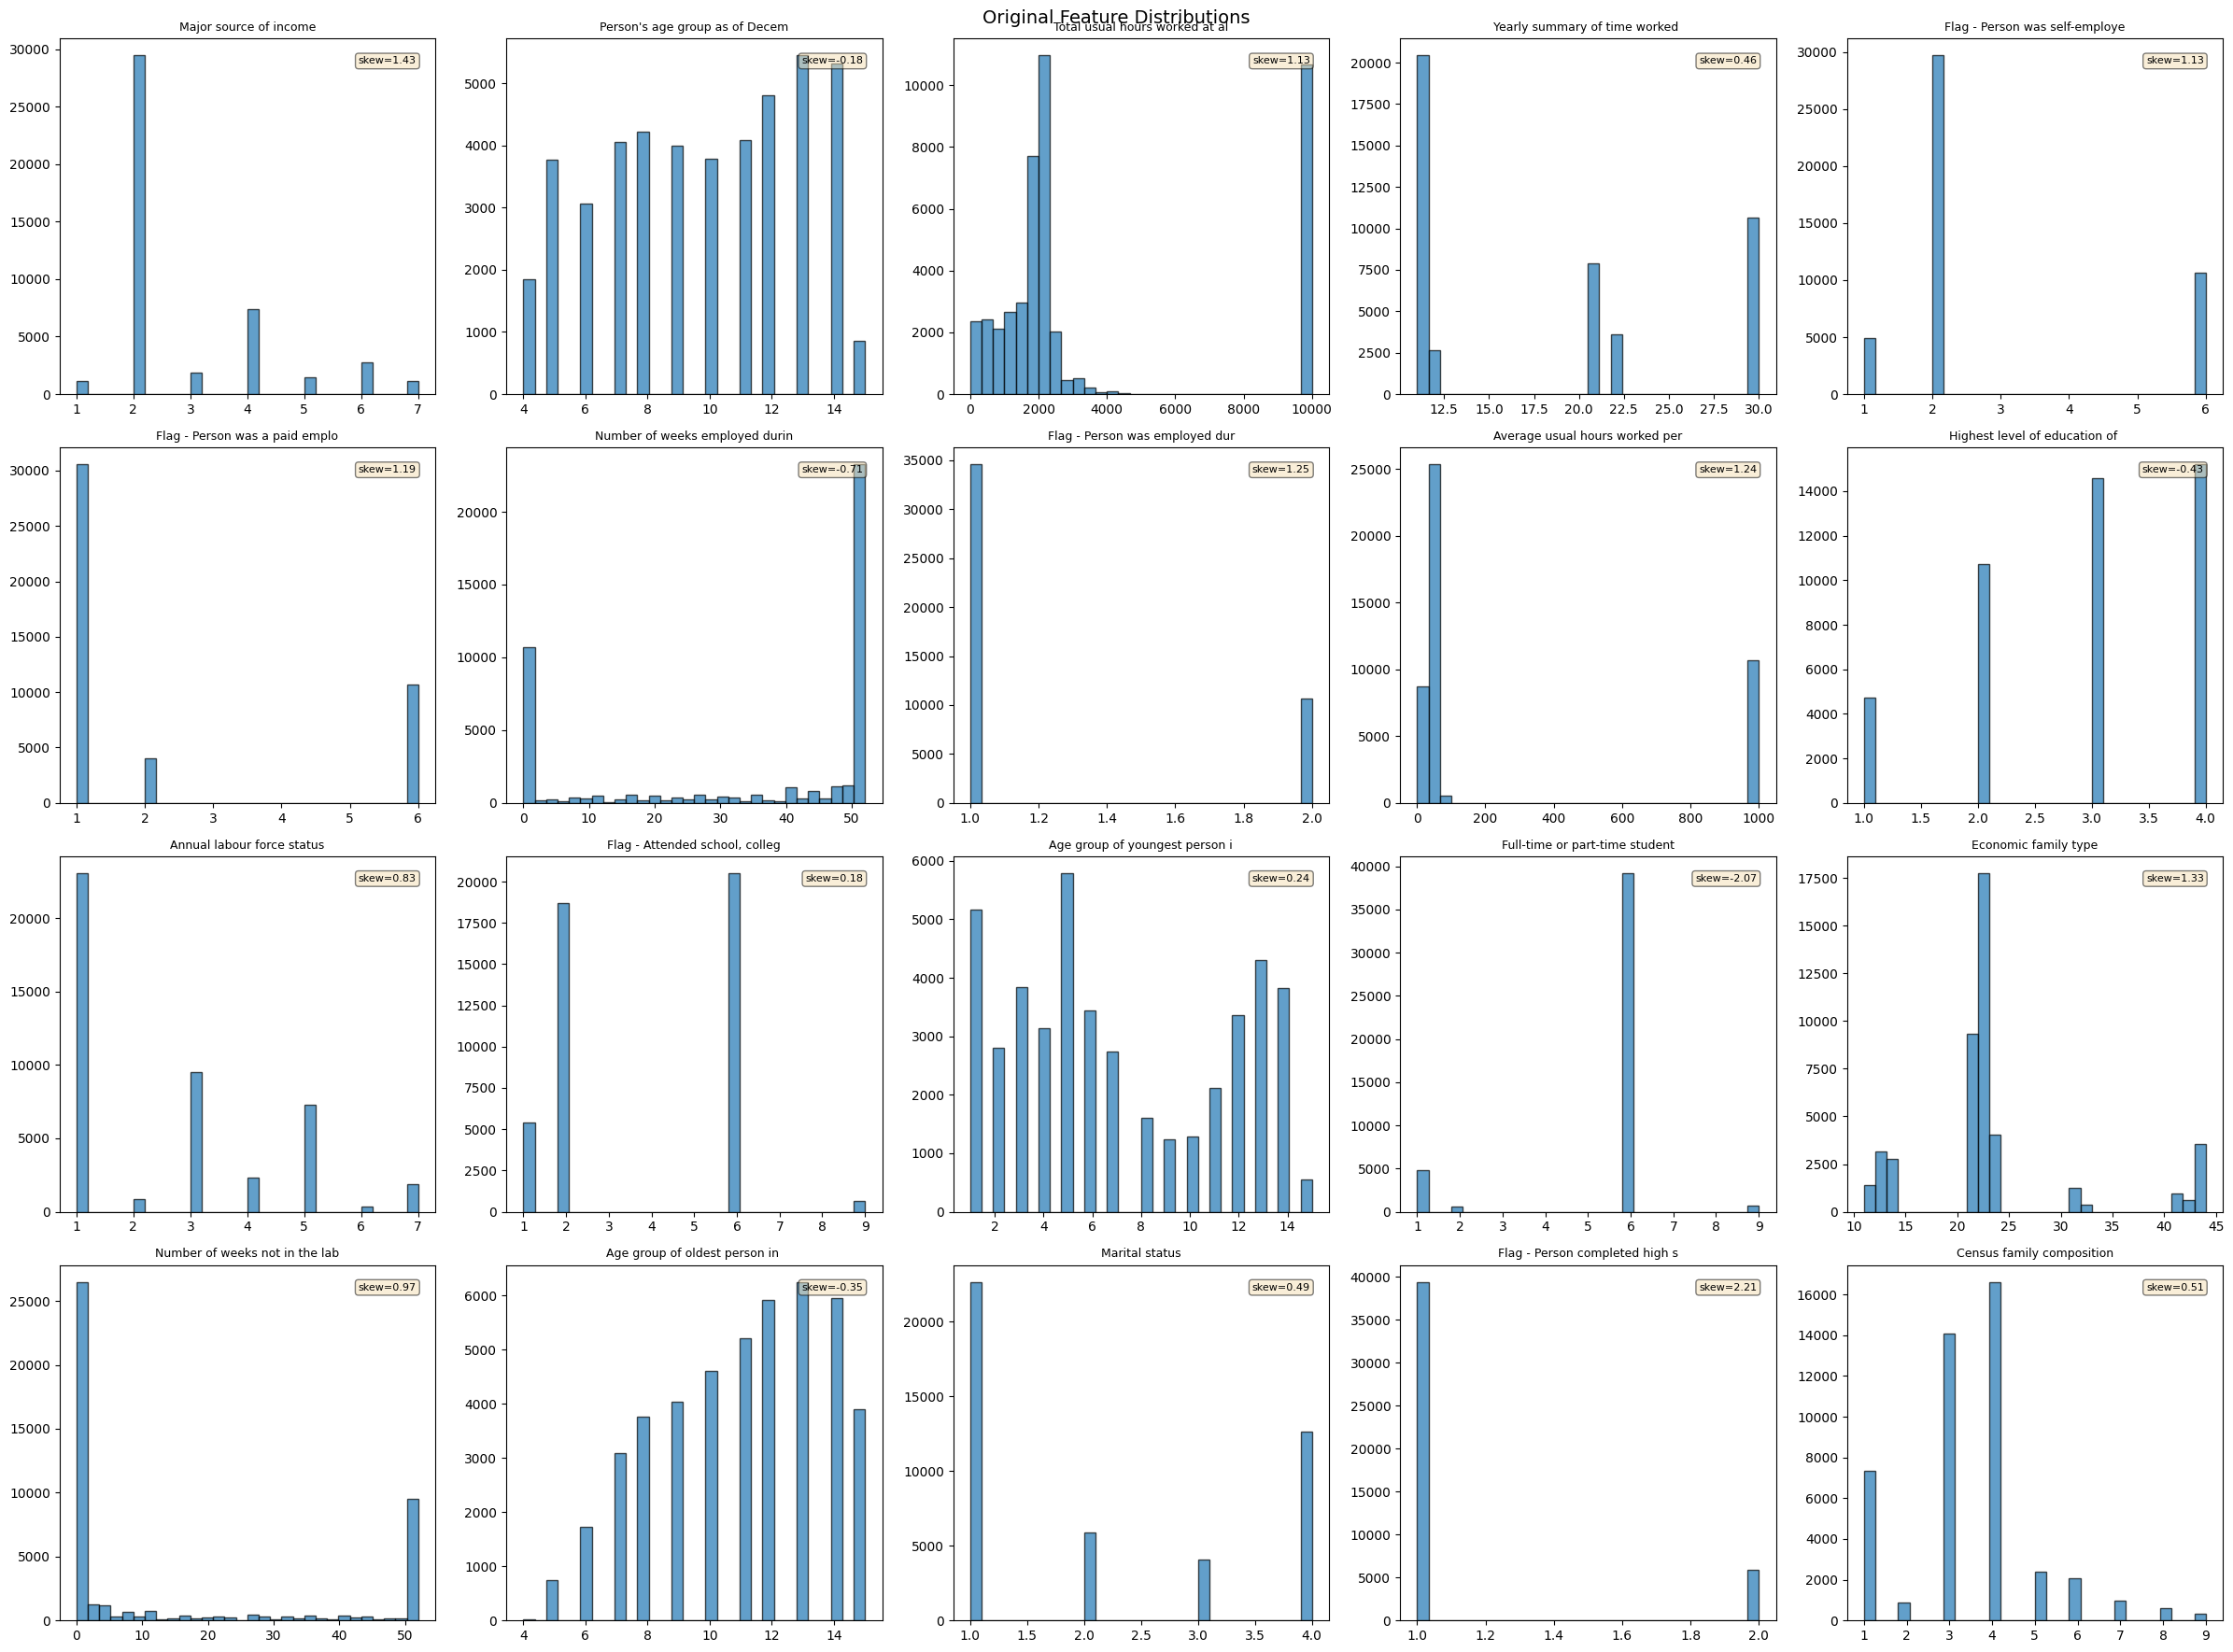

In [25]:
# Feature distributions — original
fig, axes = plt.subplots(4, 5, figsize=(24, 18))
for i, col in enumerate(features):
    ax = axes[i // 5][i % 5]
    ax.hist(X_train[col], bins=30, edgecolor='black', alpha=0.7)
    ax.set_title(col[:30], fontsize=9)
    ax.text(0.95, 0.95, f'skew={X_train[col].skew():.2f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.suptitle('Original Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

## Task 1: Apply Best Transformation Per Feature

In [26]:
# 4 Transformations: Log, Square-root, Box-Cox, Robust Scaling
# For each feature, pick the one that minimizes |skewness|

def apply_log(series):
    shift = series.min()
    if shift <= 0:
        shifted = series - shift + 1
    else:
        shifted = series
    return np.log1p(shifted), 'Log'

def apply_sqrt(series):
    shift = series.min()
    if shift < 0:
        shifted = series - shift
    else:
        shifted = series
    return np.sqrt(shifted), 'Square-root'

def apply_boxcox(series):
    shift = series.min()
    if shift <= 0:
        shifted = series - shift + 1
    else:
        shifted = series
    try:
        transformed, _ = stats.boxcox(shifted)
        return pd.Series(transformed, index=series.index), 'Box-Cox'
    except:
        return series, 'Box-Cox (failed)'

def apply_robust(series):
    scaler = RobustScaler()
    transformed = scaler.fit_transform(series.values.reshape(-1, 1)).flatten()
    return pd.Series(transformed, index=series.index), 'Robust Scaling'

transformations = [apply_log, apply_sqrt, apply_boxcox, apply_robust]

best_transforms = {}
transform_results = {}

for col in features:
    original_skew = abs(X_train[col].skew())
    best_skew = original_skew
    best_name = 'None (Original)'
    best_data = X_train[col]

    for func in transformations:
        transformed, name = func(X_train[col])
        skew = abs(transformed.skew())
        if skew < best_skew:
            best_skew = skew
            best_name = name
            best_data = transformed

    best_transforms[col] = best_name
    transform_results[col] = {
        'original_skew': round(X_train[col].skew(), 3),
        'new_skew': round(best_data.skew(), 3),
        'transform': best_name
    }

transform_summary = pd.DataFrame(transform_results).T
transform_summary.index.name = 'Feature'
transform_summary

,original_skew,new_skew,transform
Feature,,,
Major source of income,1.434,-0.026,Box-Cox
Person's age group as of December 31 of refyear,-0.178,-0.157,Box-Cox
Total usual hours worked at all jobs during refyear,1.133,0.017,Box-Cox
Yearly summary of time worked during the refyear,0.461,0.169,Box-Cox
Flag - Person was self-employed during refyear,1.133,0.034,Box-Cox
Flag - Person was a paid employee during refyear,1.19,0.829,Box-Cox
Number of weeks employed during refyear,-0.714,-0.714,Robust Scaling
Flag - Person was employed during the reference year,1.246,1.246,Square-root
Average usual hours worked per week at all jobs during refyear,1.244,-0.018,Box-Cox


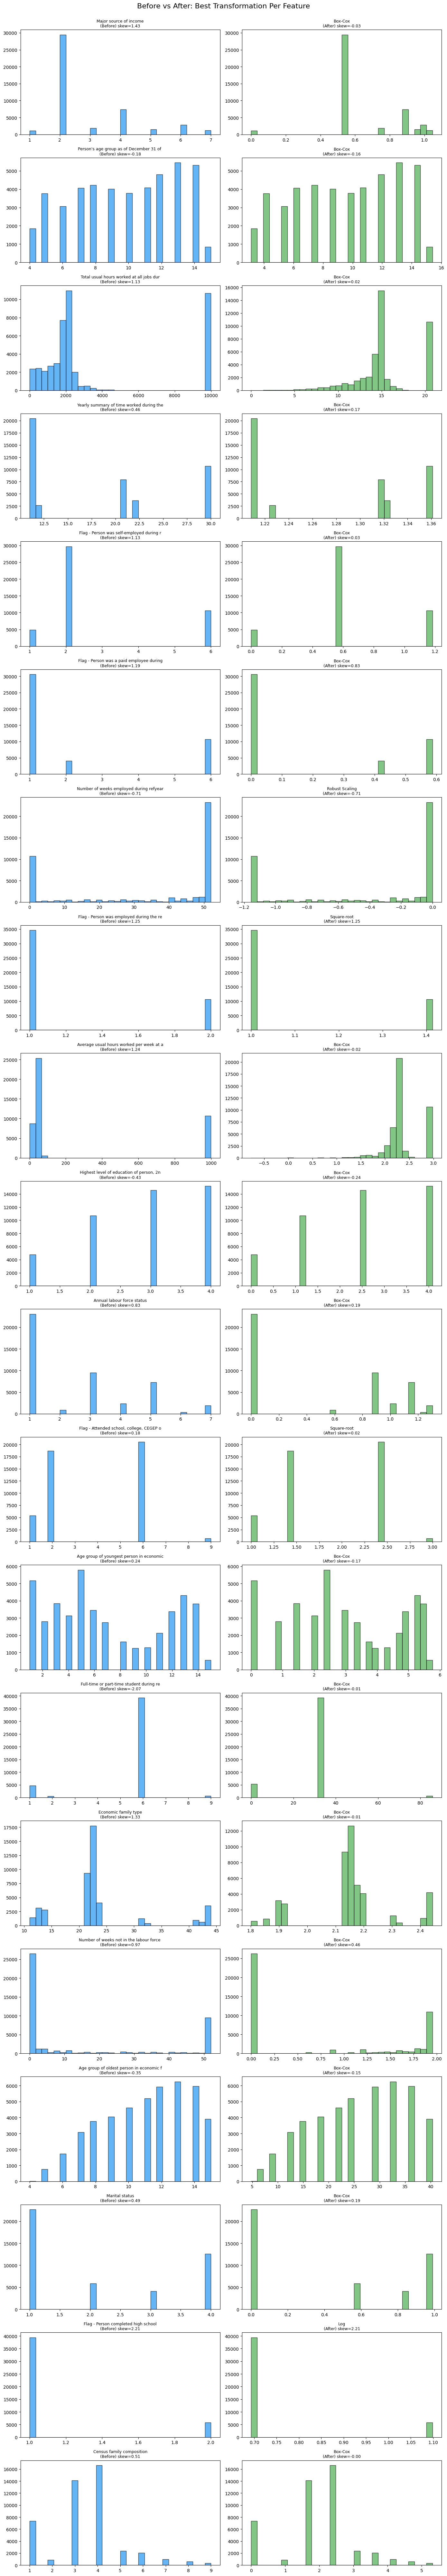

In [27]:
# 20 Before vs After graphs (one per feature, 2 columns: before | after)
fig, axes = plt.subplots(20, 2, figsize=(14, 80))

transform_funcs = {
    'Log': apply_log,
    'Square-root': apply_sqrt,
    'Box-Cox': apply_boxcox,
    'Robust Scaling': apply_robust,
    'None (Original)': lambda s: (s, 'Original'),
}

for i, col in enumerate(features):
    # Before
    axes[i][0].hist(X_train[col], bins=30, edgecolor='black', alpha=0.7, color='#2196F3')
    axes[i][0].set_title(f'{col[:40]}\n(Before) skew={X_train[col].skew():.2f}', fontsize=9)

    # After
    best_name = best_transforms[col]
    func = transform_funcs[best_name]
    transformed, _ = func(X_train[col])
    axes[i][1].hist(transformed, bins=30, edgecolor='black', alpha=0.7, color='#4CAF50')
    axes[i][1].set_title(f'{best_name}\n(After) skew={transformed.skew():.2f}', fontsize=9)

plt.suptitle('Before vs After: Best Transformation Per Feature', fontsize=16, y=1.0)
plt.tight_layout()
plt.show()

In [28]:
# Build transformed train and test sets
def transform_dataset(X_data, best_transforms_map):
    X_new = X_data.copy()
    for col in X_data.columns:
        best_name = best_transforms_map[col]
        if best_name == 'None (Original)':
            continue
        func = transform_funcs[best_name]
        X_new[col], _ = func(X_data[col])
    return X_new

X_train_transformed = transform_dataset(X_train, best_transforms)
X_test_transformed = transform_dataset(X_test, best_transforms)

print('Transformed train shape:', X_train_transformed.shape)
print('Transformed test shape:', X_test_transformed.shape)

Transformed train shape: (45258, 20)
Transformed test shape: (11315, 20)


## Model Performance: Before vs After Transformation

In [ ]:
# Models on transformed features — test on original test set
# StandardScaler for SVR on transformed data
scaler_transformed = StandardScaler()
X_train_trans_scaled = pd.DataFrame(scaler_transformed.fit_transform(X_train_transformed), columns=X_train_transformed.columns, index=X_train_transformed.index)
X_test_trans_scaled = pd.DataFrame(scaler_transformed.transform(X_test_transformed), columns=X_test_transformed.columns, index=X_test_transformed.index)

transformed_models = {
    'Decision Tree': (DecisionTreeRegressor(random_state=42), X_train_transformed, X_test_transformed),
    'Random Forest': (RandomForestRegressor(n_estimators=100, random_state=42), X_train_transformed, X_test_transformed),
    'SVR': (SVR(), X_train_trans_scaled, X_test_trans_scaled),
}

transformed_results = {}
for name, (model, X_tr, X_te) in transformed_models.items():
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    transformed_results[name] = evaluate(y_test, y_pred, n_feat)

transformed_df = pd.DataFrame(transformed_results).T
transformed_df

In [ ]:
# Before vs After comparison table
comparison = pd.DataFrame({
    'DT (Before)': baseline_results['Decision Tree'],
    'DT (After)': transformed_results['Decision Tree'],
    'RF (Before)': baseline_results['Random Forest'],
    'RF (After)': transformed_results['Random Forest'],
    'SVR (Before)': baseline_results['SVR'],
    'SVR (After)': transformed_results['SVR'],
}).T
comparison

In [ ]:
# Visual comparison: Before vs After for each metric
fig, axes = plt.subplots(1, 4, figsize=(22, 6))
metrics = ['R2', 'Adj_R2', 'RMSE', 'MAE']
model_names = ['Decision Tree', 'Random Forest', 'SVR']
x = np.arange(len(model_names))
width = 0.35

for idx, metric in enumerate(metrics):
    before_vals = [baseline_results[m][metric] for m in model_names]
    after_vals = [transformed_results[m][metric] for m in model_names]

    axes[idx].bar(x - width/2, before_vals, width, label='Before', color='#2196F3')
    axes[idx].bar(x + width/2, after_vals, width, label='After', color='#4CAF50')
    axes[idx].set_title(metric)
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(['DT', 'RF', 'SVR'])
    axes[idx].legend()

plt.suptitle('Model Performance: Before vs After Feature Transformation', fontsize=14)
plt.tight_layout()
plt.show()

## Task 2: Hyperparameter Explanation

In [32]:
# Use transformed data for hyperparameter analysis
# Sample for SVR speed (SVR is O(n^2) so full dataset is slow)
from sklearn.model_selection import validation_curve

sample_idx = np.random.RandomState(42).choice(len(X_train_transformed), size=5000, replace=False)
X_sample = X_train_transformed.iloc[sample_idx]
y_sample = y_train.iloc[sample_idx]

# Scaled sample for SVR
scaler_sample = StandardScaler()
X_sample_scaled = pd.DataFrame(scaler_sample.fit_transform(X_sample), columns=X_sample.columns, index=X_sample.index)

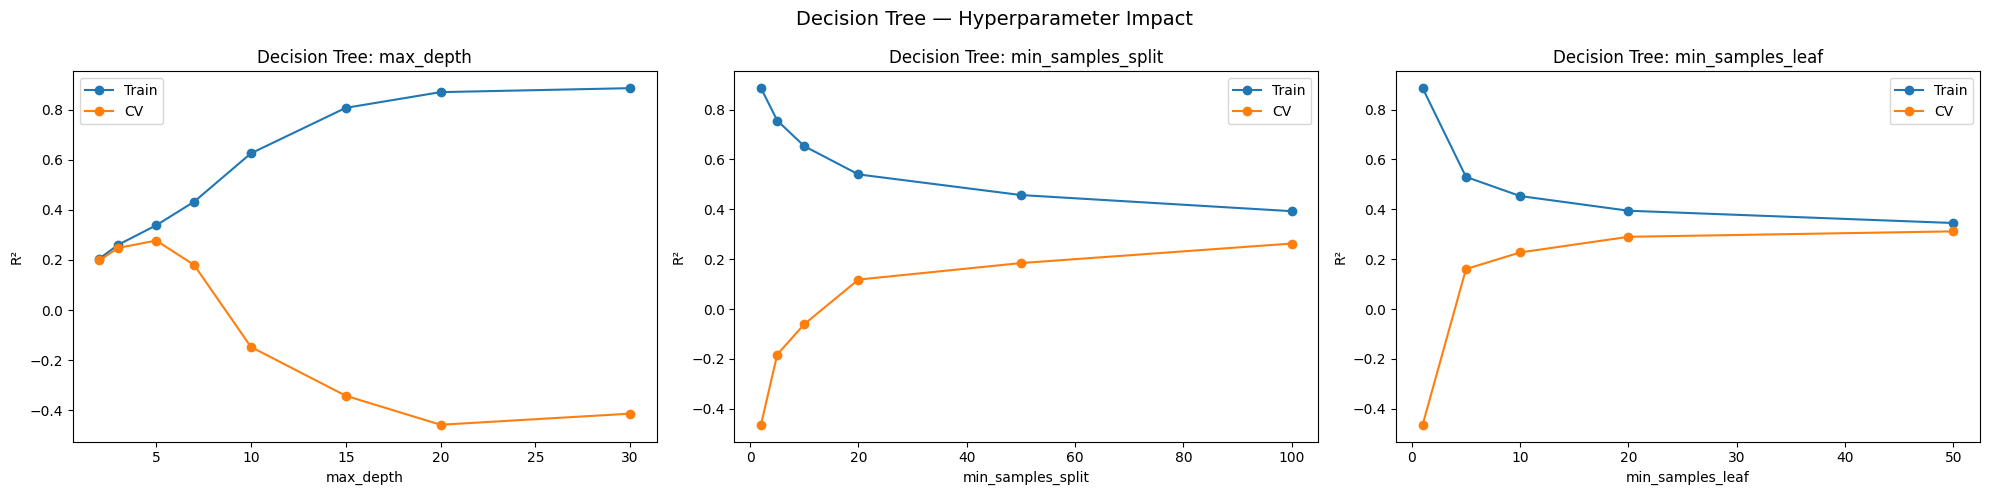

In [33]:
# Decision Tree — Validation Curves
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# max_depth
param_range = [2, 3, 5, 7, 10, 15, 20, 30]
train_scores, test_scores = validation_curve(
    DecisionTreeRegressor(random_state=42), X_sample, y_sample,
    param_name='max_depth', param_range=param_range, cv=5, scoring='r2')
axes[0].plot(param_range, train_scores.mean(axis=1), 'o-', label='Train')
axes[0].plot(param_range, test_scores.mean(axis=1), 'o-', label='CV')
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('R²')
axes[0].set_title('Decision Tree: max_depth')
axes[0].legend()

# min_samples_split
param_range2 = [2, 5, 10, 20, 50, 100]
train_scores, test_scores = validation_curve(
    DecisionTreeRegressor(random_state=42), X_sample, y_sample,
    param_name='min_samples_split', param_range=param_range2, cv=5, scoring='r2')
axes[1].plot(param_range2, train_scores.mean(axis=1), 'o-', label='Train')
axes[1].plot(param_range2, test_scores.mean(axis=1), 'o-', label='CV')
axes[1].set_xlabel('min_samples_split')
axes[1].set_ylabel('R²')
axes[1].set_title('Decision Tree: min_samples_split')
axes[1].legend()

# min_samples_leaf
param_range3 = [1, 5, 10, 20, 50]
train_scores, test_scores = validation_curve(
    DecisionTreeRegressor(random_state=42), X_sample, y_sample,
    param_name='min_samples_leaf', param_range=param_range3, cv=5, scoring='r2')
axes[2].plot(param_range3, train_scores.mean(axis=1), 'o-', label='Train')
axes[2].plot(param_range3, test_scores.mean(axis=1), 'o-', label='CV')
axes[2].set_xlabel('min_samples_leaf')
axes[2].set_ylabel('R²')
axes[2].set_title('Decision Tree: min_samples_leaf')
axes[2].legend()

plt.suptitle('Decision Tree — Hyperparameter Impact', fontsize=14)
plt.tight_layout()
plt.show()

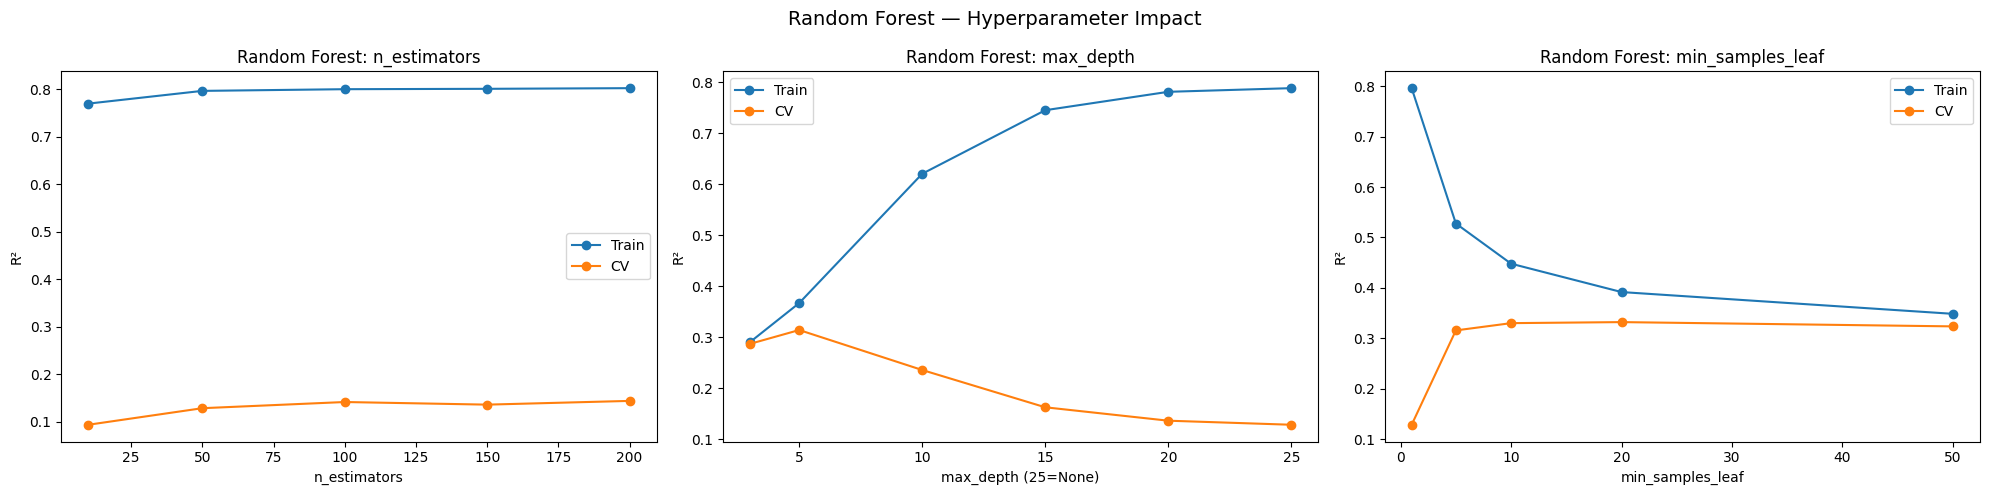

In [34]:
# Random Forest — Validation Curves
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# n_estimators
param_range = [10, 50, 100, 150, 200]
train_scores, test_scores = validation_curve(
    RandomForestRegressor(random_state=42), X_sample, y_sample,
    param_name='n_estimators', param_range=param_range, cv=5, scoring='r2')
axes[0].plot(param_range, train_scores.mean(axis=1), 'o-', label='Train')
axes[0].plot(param_range, test_scores.mean(axis=1), 'o-', label='CV')
axes[0].set_xlabel('n_estimators')
axes[0].set_ylabel('R²')
axes[0].set_title('Random Forest: n_estimators')
axes[0].legend()

# max_depth
param_range2 = [3, 5, 10, 15, 20, None]
labels2 = [3, 5, 10, 15, 20, 25]
train_scores_list, test_scores_list = [], []
for d in param_range2:
    rf = RandomForestRegressor(n_estimators=50, max_depth=d, random_state=42)
    scores = cross_val_score(rf, X_sample, y_sample, cv=5, scoring='r2')
    rf.fit(X_sample, y_sample)
    train_scores_list.append(rf.score(X_sample, y_sample))
    test_scores_list.append(scores.mean())
axes[1].plot(labels2, train_scores_list, 'o-', label='Train')
axes[1].plot(labels2, test_scores_list, 'o-', label='CV')
axes[1].set_xlabel('max_depth (25=None)')
axes[1].set_ylabel('R²')
axes[1].set_title('Random Forest: max_depth')
axes[1].legend()

# min_samples_leaf
param_range3 = [1, 5, 10, 20, 50]
train_scores, test_scores = validation_curve(
    RandomForestRegressor(n_estimators=50, random_state=42), X_sample, y_sample,
    param_name='min_samples_leaf', param_range=param_range3, cv=5, scoring='r2')
axes[2].plot(param_range3, train_scores.mean(axis=1), 'o-', label='Train')
axes[2].plot(param_range3, test_scores.mean(axis=1), 'o-', label='CV')
axes[2].set_xlabel('min_samples_leaf')
axes[2].set_ylabel('R²')
axes[2].set_title('Random Forest: min_samples_leaf')
axes[2].legend()

plt.suptitle('Random Forest — Hyperparameter Impact', fontsize=14)
plt.tight_layout()
plt.show()

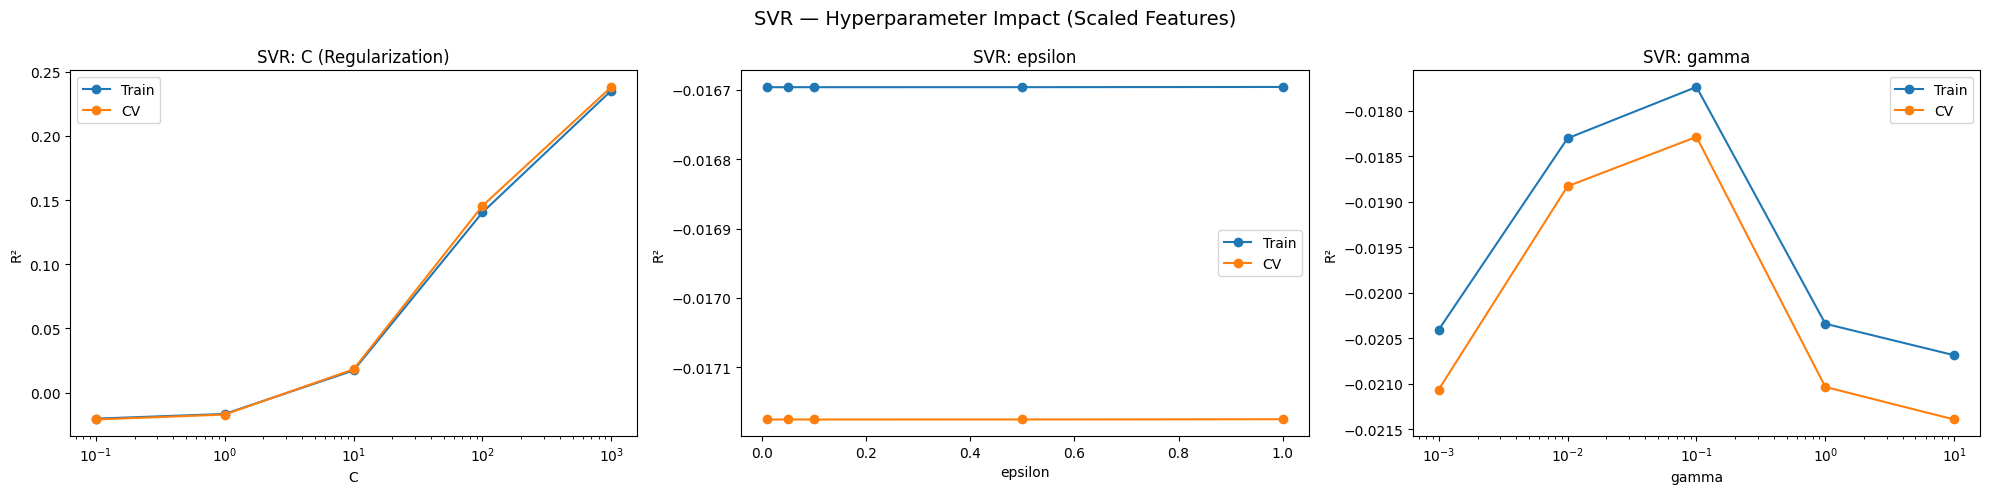

In [35]:
# SVR — Validation Curves (using scaled sample)
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# C
param_range = [0.1, 1, 10, 100, 1000]
train_scores, test_scores = validation_curve(
    SVR(kernel='rbf'), X_sample_scaled, y_sample,
    param_name='C', param_range=param_range, cv=5, scoring='r2')
axes[0].plot(param_range, train_scores.mean(axis=1), 'o-', label='Train')
axes[0].plot(param_range, test_scores.mean(axis=1), 'o-', label='CV')
axes[0].set_xlabel('C')
axes[0].set_xscale('log')
axes[0].set_ylabel('R²')
axes[0].set_title('SVR: C (Regularization)')
axes[0].legend()

# epsilon
param_range2 = [0.01, 0.05, 0.1, 0.5, 1.0]
train_scores, test_scores = validation_curve(
    SVR(kernel='rbf'), X_sample_scaled, y_sample,
    param_name='epsilon', param_range=param_range2, cv=5, scoring='r2')
axes[1].plot(param_range2, train_scores.mean(axis=1), 'o-', label='Train')
axes[1].plot(param_range2, test_scores.mean(axis=1), 'o-', label='CV')
axes[1].set_xlabel('epsilon')
axes[1].set_ylabel('R²')
axes[1].set_title('SVR: epsilon')
axes[1].legend()

# gamma
param_range3 = [0.001, 0.01, 0.1, 1, 10]
train_scores, test_scores = validation_curve(
    SVR(kernel='rbf'), X_sample_scaled, y_sample,
    param_name='gamma', param_range=param_range3, cv=5, scoring='r2')
axes[2].plot(param_range3, train_scores.mean(axis=1), 'o-', label='Train')
axes[2].plot(param_range3, test_scores.mean(axis=1), 'o-', label='CV')
axes[2].set_xlabel('gamma')
axes[2].set_xscale('log')
axes[2].set_ylabel('R²')
axes[2].set_title('SVR: gamma')
axes[2].legend()

plt.suptitle('SVR — Hyperparameter Impact (Scaled Features)', fontsize=14)
plt.tight_layout()
plt.show()

In [36]:
import gc

del baseline_models, transformed_models
del outlier_summary, outlier_df, transform_summary
del X_sample, y_sample
gc.collect()

213418